In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the merged dataset
df = pd.read_csv("../data/processed/daily_pollutants.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (35933910, 5)


,country,station,date,pollutant,value
0,DE,DE/SPO.DE_DEBB032_CO_dataGroup1,2013-01-01,CO,0.241667
1,DE,DE/SPO.DE_DEBB032_CO_dataGroup1,2013-01-02,CO,0.208333
2,DE,DE/SPO.DE_DEBB032_CO_dataGroup1,2013-01-03,CO,0.223750
3,DE,DE/SPO.DE_DEBB032_CO_dataGroup1,2013-01-04,CO,0.186250
4,DE,DE/SPO.DE_DEBB032_CO_dataGroup1,2013-01-05,CO,0.209167


In [6]:
# Basic info
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Countries: {sorted(df['country'].unique())}")
print(f"Pollutants: {sorted(df['pollutant'].unique())}")
print(f"Stations: {df['station'].nunique()}")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nValue stats:")
df['value'].describe()

Date range: 2009-01-01 to 2025-01-01
Countries: ['DE', 'ES', 'FR', 'IT', 'NL', 'PL']
Pollutants: ['CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2']
Stations: 12996

Missing values:
country      0
station      0
date         0
pollutant    0
value        0
dtype: int64

Value stats:


count    3.593391e+07
mean     2.234505e+01
std      2.312720e+01
min      0.000000e+00
25%      5.686965e+00
50%      1.436458e+01
75%      3.087500e+01
max      9.900000e+02
Name: value, dtype: float64

In [7]:
# Rows per country x pollutant
pivot = df.groupby(["country", "pollutant"]).size().unstack(fill_value=0)
print(pivot)

# Date range per country
print("\nDate range per country:")
for c in sorted(df["country"].unique()):
    sub = df[df["country"] == c]
    print(f"  {c}: {sub['date'].min()} to {sub['date'].max()}  ({sub['station'].nunique()} stations)")

pollutant      CO      NO2       O3     PM10    PM2.5      SO2
country                                                       
DE         391450  1808965  1180513  2101513  1128701   516869
ES         868067  2128714  2278333  1753010   911490  1733377
FR          93100  1736102  1385966  1552988   735833   521167
IT         853033  2483295  1362737  1936332   981865   873732
NL          38194   314507   189971   296655   168620    59244
PL         304030   591872   409102  1240026   505278   499259

Date range per country:
  DE: 2012-12-18 to 2024-12-31  (2632 stations)
  ES: 2009-01-01 to 2025-01-01  (3095 stations)
  FR: 2012-12-31 to 2025-01-01  (2252 stations)
  IT: 2013-01-01 to 2024-12-31  (3097 stations)
  NL: 2013-01-01 to 2024-12-31  (313 stations)
  PL: 2013-01-01 to 2024-12-31  (1607 stations)


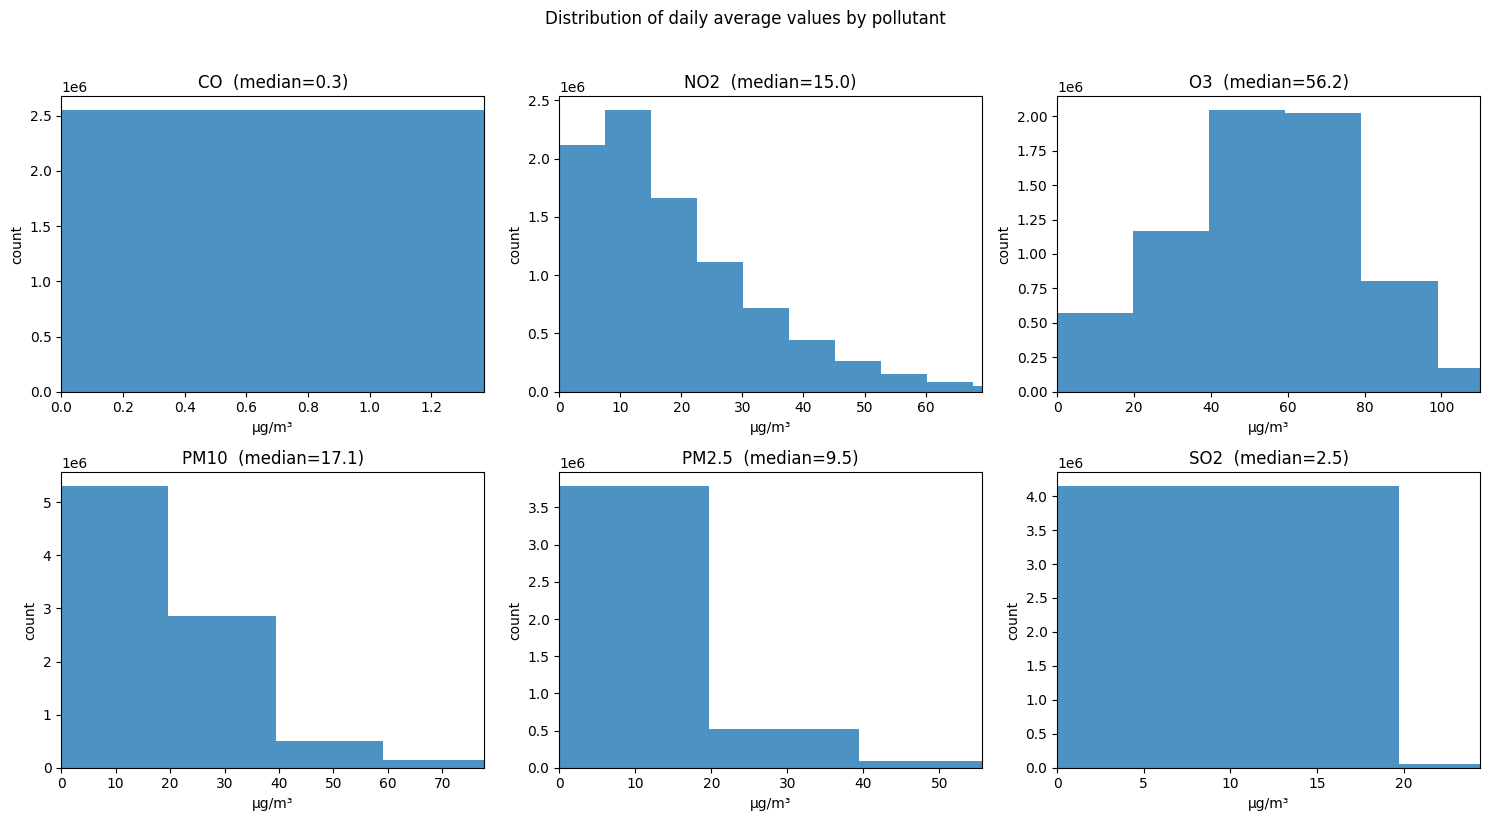

In [8]:
# Distribution of values per pollutant
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, poll in enumerate(sorted(df["pollutant"].unique())):
    sub = df[df["pollutant"] == poll]
    axes[i].hist(sub["value"], bins=50, edgecolor="none", alpha=0.8)
    axes[i].set_title(f"{poll}  (median={sub['value'].median():.1f})")
    axes[i].set_xlabel("µg/m³")
    axes[i].set_ylabel("count")
    # Cut off extreme tail for readability
    axes[i].set_xlim(0, sub["value"].quantile(0.99))

plt.suptitle("Distribution of daily average values by pollutant", y=1.02)
plt.tight_layout()
plt.show()

It's clear that CO and SO2 are concentrated near zero—low levels at most stations. O3 is interesting, its more uniform, with a median of 56.2. PM10 and PM2.5 are in the classic right tail.

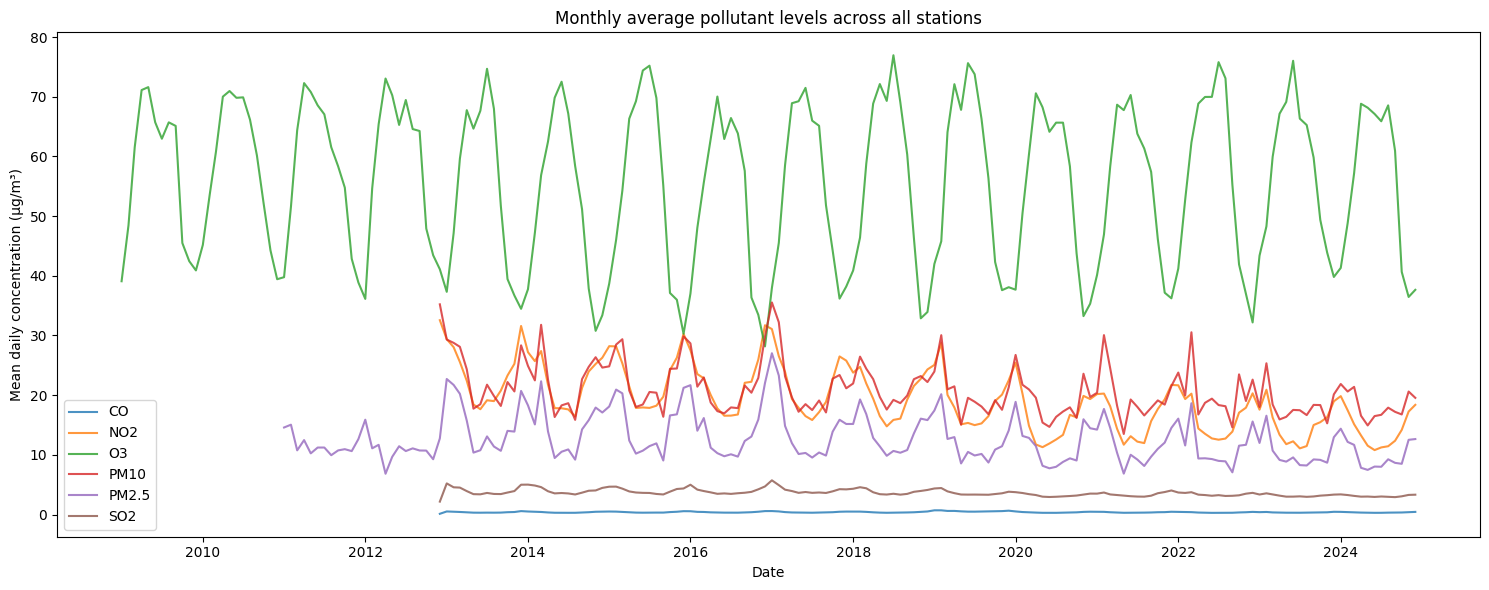

In [9]:
# Monthly average trend per pollutant
df["date"] = pd.to_datetime(df["date"])
df["year_month"] = df["date"].dt.to_period("M")

# Filter out 2025
df = df[df["date"].dt.year < 2025]

monthly = df.groupby(["year_month", "pollutant"])["value"].mean().reset_index()
monthly["year_month"] = monthly["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 6))
for poll in sorted(df["pollutant"].unique()):
    sub = monthly[monthly["pollutant"] == poll]
    ax.plot(sub["year_month"], sub["value"], label=poll, alpha=0.8)

ax.set_xlabel("Date")
ax.set_ylabel("Mean daily concentration (µg/m³)")
ax.set_title("Monthly average pollutant levels across all stations")
ax.legend()
plt.tight_layout()
plt.show()

So there we can see some patterns actually:

O3 (green): strong seasonality, peaks in summer. This makes sense, as ozone is formed under the influence of sunlight.
PM10, NO2, and PM2.5: conversely, peaks in winter. In winter, there's more heating, and dispersion is worse due to inversions.
CO and SO2: low and stable, near zero.
This is great news for the model; 
seasonality means that time features (month, season) will be predictive.

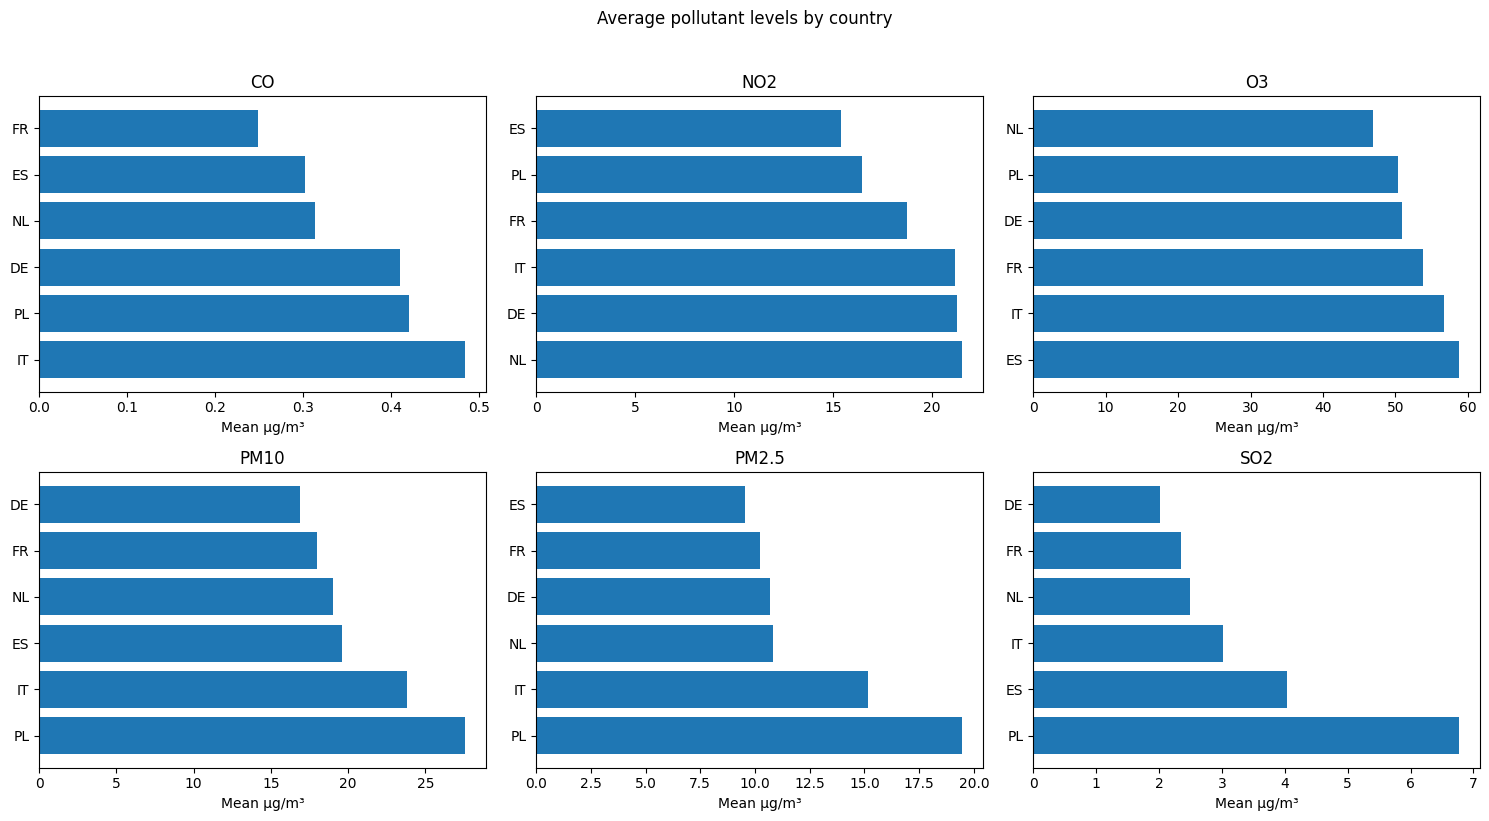

In [10]:
# Average pollutant levels per country
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, poll in enumerate(sorted(df["pollutant"].unique())):
    sub = df[df["pollutant"] == poll]
    country_avg = sub.groupby("country")["value"].mean().sort_values(ascending=False)
    axes[i].barh(country_avg.index, country_avg.values)
    axes[i].set_title(poll)
    axes[i].set_xlabel("Mean µg/m³")

plt.suptitle("Average pollutant levels by country", y=1.02)
plt.tight_layout()
plt.show()

Interesting differences. Poland leads in PM10 and SO2: a lot of coal heating. Spain has NO2 and PM2.5, likely due to traffic and dust i guess. The Netherlands has high O3 but low NO2, an interesting combination. All of this will be nicely mapped later on the website (i hope).

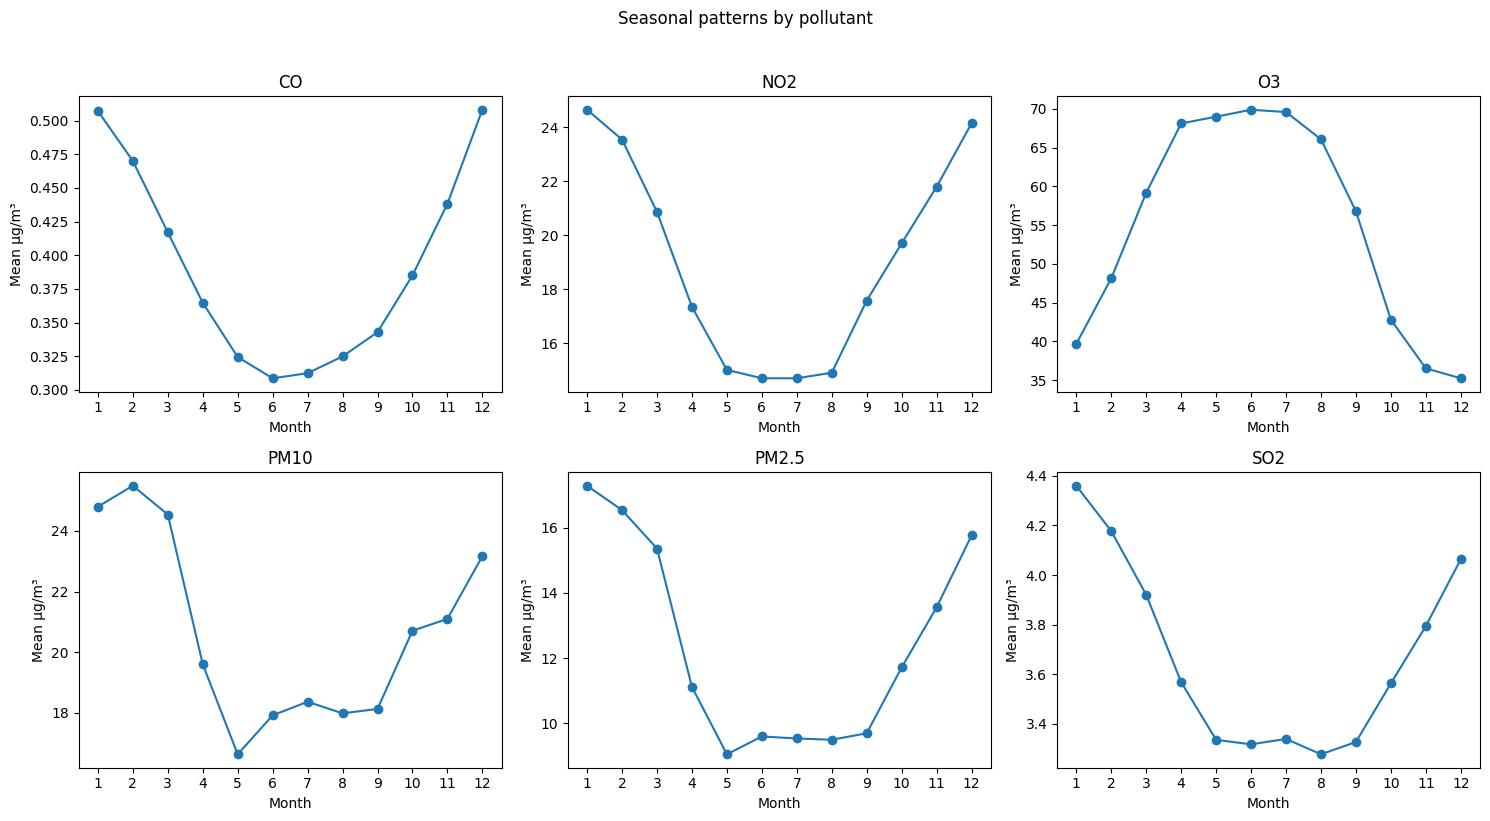

In [11]:
# Seasonal patterns
df["month"] = df["date"].dt.month

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, poll in enumerate(sorted(df["pollutant"].unique())):
    sub = df[df["pollutant"] == poll]
    monthly_avg = sub.groupby("month")["value"].mean()
    axes[i].plot(monthly_avg.index, monthly_avg.values, marker="o")
    axes[i].set_title(poll)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Mean µg/m³")

plt.suptitle("Seasonal patterns by pollutant", y=1.02)
plt.tight_layout()
plt.show()

We can see seasonality distinctly

Winter pollutants (CO, NO2, PM10, PM2.5, SO2) peak in January-February and December. 
Causes: heating, temperature inversions, less wind. 
Summer pollutants (O3) peak in June-July. Ozone is formed photochemically—more sun = more O3.


This means that the month and season features will definitely fit into the model.

• 35.9M rows, 12996 stations, 6 countries, 6 pollutants.
• Zero gaps.
• Strong seasonality.
• Differences between countries.
• 2025 removed.